# Manipulation Technique Classifier - Legal-BERT
**Stage 3: Multi-label technique classification thay thế Evidence Agent**

## 1. Install & Import

In [1]:
!pip install transformers datasets scikit-learn torch accelerate -q

In [2]:
import os
import re
import json
import warnings
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from transformers import (
    AutoTokenizer,
    AutoModel,
    get_linear_schedule_with_warmup
)
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    f1_score, precision_score, recall_score,
    classification_report
)
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')
 
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {DEVICE}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Device: cuda
GPU: Tesla T4
VRAM: 15.6 GB


## 2. Config - Chỉnh sửa ở đây

In [3]:
TRAIN_CSV  = "/kaggle/input/datasets/linhtron123/legaldata/train_split.csv"
VAL_CSV    = "/kaggle/input/datasets/linhtron123/legaldata/val_split.csv"
TEST_CSV   = "/kaggle/input/datasets/linhtron123/test-intent-p2/test_intent.csv"
OUTPUT_DIR = "/kaggle/working/bert_classifier"
os.makedirs(OUTPUT_DIR, exist_ok=True)
 
COL_DIALOGUE   = "Dialogue"
COL_TECHNIQUES = "Manipulation Techniques"
COL_PLAINTIFF  = "PLAINTIFF"
COL_DEFENDANT  = "DEFENDANT"
 
BASE_MODEL = "nlpaueb/legal-bert-base-uncased"
MAX_LENGTH = 512
 
BATCH_SIZE    = 8
GRAD_ACCUM    = 4
EPOCHS        = 30
FREEZE_EPOCHS = 3
LR_ENCODER    = 1e-5
LR_HEAD       = 1e-4
DROPOUT       = 0.4
WEIGHT_DECAY  = 0.01
VAL_SPLIT     = 0.15
PATIENCE      = 7
SEED          = 42
 
TECHNIQUES = [
    "persuasion",
    "playing the victim",
    "gaslighting",
    "evasion",
    "deflection",
    "minimization",
    "dismissal",
    "guilt tripping",
    "emotional appeal",
    "framing the narrative",
    "character attack"
]
NUM_LABELS = len(TECHNIQUES)
 
torch.manual_seed(SEED)
np.random.seed(SEED)
 
print(f"Config loaded.")
print(f"  Model:      {BASE_MODEL}")
print(f"  Techniques: {NUM_LABELS}")
print(f"  Batch:      {BATCH_SIZE} x {GRAD_ACCUM} = {BATCH_SIZE * GRAD_ACCUM} effective")
print(f"  Epochs:     {EPOCHS} (early stop patience={PATIENCE})")
print(f"  Freeze:     encoder frozen for first {FREEZE_EPOCHS} epochs")

Config loaded.
  Model:      nlpaueb/legal-bert-base-uncased
  Techniques: 11
  Batch:      8 x 4 = 32 effective
  Epochs:     30 (early stop patience=7)
  Freeze:     encoder frozen for first 3 epochs


## 3. Load & Explore Data

In [4]:
def parse_techniques(tech_str):
    """Parse comma-separated technique string thành list."""
    if pd.isna(tech_str) or str(tech_str).strip().lower() in ['none', 'nan', '']:
        return []
    result = []
    for t in str(tech_str).split(','):
        t_clean = t.strip().lower()
        if t_clean in TECHNIQUES:
            result.append(t_clean)
    return result

def load_data(csv_path):
    df = pd.read_csv(csv_path)
    print(f"Loaded {len(df)} rows from {csv_path}")
    print(f"Columns: {list(df.columns)}")
    return df

train_df = load_data(TRAIN_CSV)
train_df['techniques_list'] = train_df[COL_TECHNIQUES].apply(parse_techniques)
 
print("\n=== Label Distribution ===")
all_techniques = [t for sublist in train_df['techniques_list'] for t in sublist]
counter = Counter(all_techniques)
for tech in TECHNIQUES:
    count = counter.get(tech, 0)
    bar = '█' * min(count, 50)
    print(f"  {tech:<25} {count:>4}  {bar}")
 
print(f"\nSamples with NO technique: {sum(1 for t in train_df['techniques_list'] if len(t) == 0)}")
print(f"Samples with techniques:   {sum(1 for t in train_df['techniques_list'] if len(t) > 0)}")

Loaded 720 rows from /kaggle/input/datasets/linhtron123/legaldata/train_split.csv
Columns: ['Dialogue', 'Manipulative', 'Primary Manipulator', 'Manipulation Techniques']

=== Label Distribution ===
  persuasion                  74  ██████████████████████████████████████████████████
  playing the victim         128  ██████████████████████████████████████████████████
  gaslighting                142  ██████████████████████████████████████████████████
  evasion                    146  ██████████████████████████████████████████████████
  deflection                 272  ██████████████████████████████████████████████████
  minimization               149  ██████████████████████████████████████████████████
  dismissal                   27  ███████████████████████████
  guilt tripping              27  ███████████████████████████
  emotional appeal           100  ██████████████████████████████████████████████████
  framing the narrative       36  ████████████████████████████████████
  character 

## 4. Data Augmentation cho Rare Classes

In [5]:
def compute_oversample_weights(df, rare_threshold=50):  
    """
    Tính số lần duplicate mỗi sample dựa trên rare techniques.
    """
    all_tech = [t for sublist in df['techniques_list'] for t in sublist]
    counts = Counter(all_tech)
 
    rare = {t: c for t, c in counts.items() if c <= rare_threshold}
    print(f"Rare techniques (support <= {rare_threshold}):")
    for t, c in sorted(rare.items(), key=lambda x: x[1]):
        oversample = min(int(rare_threshold / max(c, 1)), 5)
        print(f"  {t:<25} support={c}  → oversample {oversample}x")
 
    weights = []
    for tech_list in df['techniques_list']:
        max_weight = 1
        for t in tech_list:
            if t in rare:
                w = min(int(rare_threshold / max(rare[t], 1)), 5)
                max_weight = max(max_weight, w)
        weights.append(max_weight)
 
    return weights

def augment_dataframe(df, weights):
    """Duplicate rows theo weight, shuffle kết quả."""
    rows = []
    for (_, row), w in zip(df.iterrows(), weights):
        rows.extend([row] * w)
    augmented = pd.DataFrame(rows).reset_index(drop=True)
    augmented = augmented.sample(frac=1, random_state=SEED).reset_index(drop=True)
    print(f"\nAugmented: {len(df)} → {len(augmented)} samples")
    return augmented
 
 
weights = compute_oversample_weights(train_df, rare_threshold=50)
train_df_aug = augment_dataframe(train_df, weights)

Rare techniques (support <= 50):
  character attack          support=10  → oversample 5x
  guilt tripping            support=27  → oversample 1x
  dismissal                 support=27  → oversample 1x
  framing the narrative     support=36  → oversample 1x

Augmented: 720 → 760 samples


## 5. Build Input Text & Binarize Labels

In [6]:
def build_input_text(row, use_intent=True):
    dialogue = str(row[COL_DIALOGUE]).strip()
 
    if use_intent and COL_PLAINTIFF and COL_DEFENDANT:
        try:
            plaintiff = str(row[COL_PLAINTIFF]).strip() if pd.notna(row.get(COL_PLAINTIFF)) else ""
            defendant = str(row[COL_DEFENDANT]).strip() if pd.notna(row.get(COL_DEFENDANT)) else ""
            if plaintiff or defendant:
                return f"[PLAINTIFF INTENT] {plaintiff} [DEFENDANT INTENT] {defendant} [DIALOGUE] {dialogue}"
        except:
            pass
 
    return dialogue

mlb = MultiLabelBinarizer(classes=TECHNIQUES)
mlb.fit([TECHNIQUES])
 
HAS_INTENT_IN_TRAIN = COL_PLAINTIFF in train_df.columns
 
train_texts  = [build_input_text(row, use_intent=HAS_INTENT_IN_TRAIN)
                for _, row in train_df_aug.iterrows()]
train_labels = mlb.transform(train_df_aug['techniques_list'])
 
if VAL_CSV and os.path.exists(VAL_CSV):
    val_df = load_data(VAL_CSV)
    val_df['techniques_list'] = val_df[COL_TECHNIQUES].apply(parse_techniques)
    HAS_INTENT_IN_VAL = COL_PLAINTIFF in val_df.columns
    val_texts  = [build_input_text(row, use_intent=HAS_INTENT_IN_VAL)
                  for _, row in val_df.iterrows()]
    val_labels = mlb.transform(val_df['techniques_list'])
    print(f"Val from file: {len(val_texts)} samples")
else:
    orig_texts  = [build_input_text(row, use_intent=HAS_INTENT_IN_TRAIN)
                   for _, row in train_df.iterrows()]
    orig_labels = mlb.transform(train_df['techniques_list'])
    train_texts, val_texts, train_labels, val_labels = train_test_split(
        orig_texts, orig_labels,
        test_size=VAL_SPLIT, random_state=SEED
    )
    print(f"Auto split: {len(train_texts)} train, {len(val_texts)} val")
 
print(f"\nTrain: {len(train_texts)}, Val: {len(val_texts)}")
print(f"Label shape: {train_labels.shape}")
 

Loaded 155 rows from /kaggle/input/datasets/linhtron123/legaldata/val_split.csv
Columns: ['Dialogue', 'Manipulative', 'Primary Manipulator', 'Manipulation Techniques']
Val from file: 155 samples

Train: 760, Val: 155
Label shape: (760, 11)


## 6. Dataset & DataLoader

In [7]:
class ManipulationDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=512):
        self.labels = torch.FloatTensor(labels)
 
        print(f"Tokenizing {len(texts)} samples...")
        self.encodings = tokenizer(
            texts,
            truncation=True,
            padding=True,
            max_length=max_length,
            return_tensors='pt'
        )
        print("Done.")
 
    def __len__(self):
        return len(self.labels)
 
    def __getitem__(self, idx):
        return {
            'input_ids':      self.encodings['input_ids'][idx],
            'attention_mask': self.encodings['attention_mask'][idx],
            'labels':         self.labels[idx]
        }
 
 
print(f"Loading tokenizer: {BASE_MODEL}")
tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL)
 
train_dataset = ManipulationDataset(train_texts, train_labels, tokenizer, MAX_LENGTH)
val_dataset   = ManipulationDataset(val_texts,   val_labels,   tokenizer, MAX_LENGTH)
 
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
 
print(f"Train batches: {len(train_loader)}, Val batches: {len(val_loader)}")

Loading tokenizer: nlpaueb/legal-bert-base-uncased


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Tokenizing 760 samples...
Done.
Tokenizing 155 samples...
Done.
Train batches: 95, Val batches: 20


## 7. Model Architecture

In [9]:
class ManipulationClassifier(nn.Module):
    def __init__(self, model_name, num_labels, train_labels=None, dropout=0.4):
        super().__init__()
        self.encoder   = AutoModel.from_pretrained(model_name)
        hidden_size    = self.encoder.config.hidden_size
 
        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(hidden_size, hidden_size // 2),
            nn.GELU(),
            nn.LayerNorm(hidden_size // 2),
            nn.Dropout(dropout),
            nn.Linear(hidden_size // 2, num_labels)
        )
 
        MAX_WEIGHT = 20.0
        if train_labels is not None:
            N_total = len(train_labels)
            counts  = train_labels.sum(axis=0).tolist()
            print("pos_weight computed dynamically from train_labels:")
        else:
            # fallback nếu load model từ file (không có train_labels)
            N_total = 720
            counts  = [74, 128, 142, 146, 272, 149, 27, 27, 100, 36, 10]
            print("pos_weight using fallback hardcoded values:")
 
        self.pos_weights = torch.tensor(
            [min((N_total - c) / max(c, 1), MAX_WEIGHT) for c in counts],
            dtype=torch.float
        )
        for tech, w in zip(TECHNIQUES, self.pos_weights):
            print(f"  {tech:<25} pos_weight={w:.2f}")
 
        self.loss_fct = nn.BCEWithLogitsLoss(pos_weight=self.pos_weights)
 
    def mean_pool(self, token_embeddings, attention_mask):
        mask_expanded = attention_mask.unsqueeze(-1).float()
        sum_emb       = (token_embeddings * mask_expanded).sum(dim=1)
        count         = mask_expanded.sum(dim=1).clamp(min=1e-9)
        return sum_emb / count
 
    def forward(self, input_ids, attention_mask, labels=None):
        outputs   = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        cls_repr  = outputs.last_hidden_state[:, 0, :]
        mean_repr = self.mean_pool(outputs.last_hidden_state, attention_mask)
        pooled    = (cls_repr + mean_repr) / 2
        logits    = self.classifier(pooled)
 
        loss = None
        if labels is not None:
            loss = self.loss_fct(logits, labels.to(logits.device))
 
        return loss, logits
 
    def freeze_encoder(self):
        for param in self.encoder.parameters():
            param.requires_grad = False
 
    def unfreeze_encoder(self):
        for param in self.encoder.parameters():
            param.requires_grad = True
 
model = ManipulationClassifier(
    BASE_MODEL, NUM_LABELS,
    train_labels=train_labels,
    dropout=DROPOUT
).to(DEVICE)
 
total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTotal params:     {total_params:,}")
print(f"Trainable params: {trainable_params:,}")
print(f"Pooling strategy: CLS + Mean (averaged)")
print(f"Loss function:    BCEWithLogitsLoss + pos_weight (dynamic)") 

pytorch_model.bin:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: nlpaueb/legal-bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


pos_weight computed dynamically from train_labels:
  persuasion                pos_weight=9.27
  playing the victim        pos_weight=4.43
  gaslighting               pos_weight=4.21
  evasion                   pos_weight=4.21
  deflection                pos_weight=1.68
  minimization              pos_weight=3.84
  dismissal                 pos_weight=20.00
  guilt tripping            pos_weight=20.00
  emotional appeal          pos_weight=6.60
  framing the narrative     pos_weight=18.00
  character attack          pos_weight=14.20


model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]


Total params:     109,782,539
Trainable params: 109,782,539
Pooling strategy: CLS + Mean (averaged)
Loss function:    BCEWithLogitsLoss + pos_weight (dynamic)


## 8. Training với Per-class Threshold Tuning

In [10]:
def get_all_preds_and_labels(model, loader):
    model.eval()
    all_probs, all_labels = [], []
 
    with torch.no_grad():
        for batch in loader:
            input_ids      = batch['input_ids'].to(DEVICE)
            attention_mask = batch['attention_mask'].to(DEVICE)
            labels         = batch['labels'].numpy()
 
            _, logits = model(input_ids, attention_mask)
            probs     = torch.sigmoid(logits).cpu().numpy()
 
            all_probs.append(probs)
            all_labels.append(labels)
 
    return np.concatenate(all_probs), np.concatenate(all_labels)
 
 
def tune_thresholds_constrained(probs, labels,
                                 min_precision=0.40,      # FIX: 0.25 → 0.40
                                 search_range=(0.1, 0.9, 0.05)):
    """
    Tìm threshold maximize F1 với ràng buộc precision >= min_precision.
    min_precision=0.40: ít nhất 2/5 predictions phải đúng → giảm FP mạnh hơn.
    """
    best_thresholds = np.full(NUM_LABELS, 0.5)
 
    print(f"\nPer-class threshold tuning (min_precision={min_precision}):")
    print(f"{'Technique':<25} {'Threshold':>10} {'F1':>8} {'P':>8} {'R':>8}")
    print("-" * 65)
 
    for i, technique in enumerate(TECHNIQUES):
        best_f1     = 0
        best_thresh = 0.5
 
        for thresh in np.arange(*search_range):
            preds = (probs[:, i] >= thresh).astype(int)
            p  = precision_score(labels[:, i], preds, zero_division=0)
            f1 = f1_score(labels[:, i], preds, zero_division=0)
 
            if p >= min_precision and f1 > best_f1:
                best_f1     = f1
                best_thresh = thresh
 
        best_thresholds[i] = best_thresh
        preds_final = (probs[:, i] >= best_thresh).astype(int)
        p_final  = precision_score(labels[:, i], preds_final, zero_division=0)
        r_final  = recall_score(labels[:, i], preds_final, zero_division=0)
        f1_final = f1_score(labels[:, i], preds_final, zero_division=0)
 
        print(f"  {technique:<23} {best_thresh:>10.2f} "
              f"{f1_final:>8.3f} {p_final:>8.3f} {r_final:>8.3f}")
 
    return best_thresholds
 
 
def evaluate(model, loader, thresholds=None):
    probs, labels = get_all_preds_and_labels(model, loader)
 
    if thresholds is None:
        thresholds = np.full(NUM_LABELS, 0.5)
 
    preds = (probs >= thresholds).astype(int)
 
    macro_f1  = f1_score(labels, preds, average='macro',   zero_division=0)
    micro_f1  = f1_score(labels, preds, average='micro',   zero_division=0)
    sample_f1 = f1_score(labels, preds, average='samples', zero_division=0)
 
    return macro_f1, micro_f1, sample_f1, probs, labels
 
 
# Training loop
print(f"Phase 1: Freezing encoder for {FREEZE_EPOCHS} epochs...")
model.freeze_encoder()
 
optimizer_phase1 = AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR_HEAD, weight_decay=WEIGHT_DECAY
)
 
 
def make_full_optimizer(model):
    return AdamW([
        {'params': model.encoder.parameters(),    'lr': LR_ENCODER, 'weight_decay': WEIGHT_DECAY},
        {'params': model.classifier.parameters(), 'lr': LR_HEAD,    'weight_decay': WEIGHT_DECAY}
    ])
 
 
history          = {'train_loss': [], 'val_macro_f1': [], 'val_micro_f1': []}
best_val_f1      = 0
best_thresholds  = np.full(NUM_LABELS, 0.5)
patience_counter = 0
optimizer        = optimizer_phase1
scheduler        = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=len(train_loader) * FREEZE_EPOCHS // 5,
    num_training_steps=len(train_loader) * FREEZE_EPOCHS
)
 
print("\n" + "=" * 65)
print("STARTING TRAINING")
print("=" * 65)
 
for epoch in range(EPOCHS):
    if epoch == FREEZE_EPOCHS:
        print(f"\nPhase 2: Unfreezing encoder at epoch {epoch + 1}...")
        model.unfreeze_encoder()
        optimizer = make_full_optimizer(model)
        remaining = EPOCHS - FREEZE_EPOCHS
        scheduler = get_linear_schedule_with_warmup(
            optimizer,
            num_warmup_steps=len(train_loader) * remaining // 10,
            num_training_steps=len(train_loader) * remaining
        )
        trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
        print(f"Trainable params now: {trainable:,}")
 
    model.train()
    total_loss = 0
    optimizer.zero_grad()
 
    for step, batch in enumerate(train_loader):
        input_ids      = batch['input_ids'].to(DEVICE)
        attention_mask = batch['attention_mask'].to(DEVICE)
        labels         = batch['labels'].to(DEVICE)
 
        loss, _ = model(input_ids, attention_mask, labels)
        loss    = loss / GRAD_ACCUM
        loss.backward()
 
        if (step + 1) % GRAD_ACCUM == 0 or (step + 1) == len(train_loader):
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            scheduler.step()
            optimizer.zero_grad()
 
        total_loss += loss.item() * GRAD_ACCUM
 
    avg_loss = total_loss / len(train_loader)
    phase    = "[FROZEN]" if epoch < FREEZE_EPOCHS else "[FULL  ]"
 
    macro_f1, micro_f1, sample_f1, val_probs, val_labels_arr = evaluate(model, val_loader)
 
    history['train_loss'].append(avg_loss)
    history['val_macro_f1'].append(macro_f1)
    history['val_micro_f1'].append(micro_f1)
 
    print(f"Epoch {epoch + 1:>2}/{EPOCHS} {phase} | Loss: {avg_loss:.4f} | "
          f"Macro F1: {macro_f1:.4f} | Micro F1: {micro_f1:.4f} | Sample F1: {sample_f1:.4f}")
 
    if macro_f1 > best_val_f1:
        best_val_f1     = macro_f1
        best_thresholds = tune_thresholds_constrained(
            val_probs, val_labels_arr,
            min_precision=0.40  
        )
        patience_counter = 0
        torch.save(model.state_dict(), f"{OUTPUT_DIR}/best_model.pt")
        np.save(f"{OUTPUT_DIR}/best_thresholds.npy", best_thresholds)
        print(f"  ✓ Saved best (Macro F1: {best_val_f1:.4f})")
    else:
        patience_counter += 1
        if epoch >= FREEZE_EPOCHS and patience_counter >= PATIENCE:
            print(f"\nEarly stopping at epoch {epoch + 1} (patience={PATIENCE})")
            break
 
print(f"\nBest Val Macro F1: {best_val_f1:.4f}")
 

Phase 1: Freezing encoder for 3 epochs...

STARTING TRAINING
Epoch  1/30 [FROZEN] | Loss: 1.2650 | Macro F1: 0.2046 | Micro F1: 0.2177 | Sample F1: 0.1826

Per-class threshold tuning (min_precision=0.4):
Technique                  Threshold       F1        P        R
-----------------------------------------------------------------
  persuasion                    0.50    0.217    0.122    1.000
  playing the victim            0.50    0.276    0.160    1.000
  gaslighting                   0.50    0.335    0.205    0.929
  evasion                       0.50    0.287    0.168    1.000
  deflection                    0.30    0.642    0.491    0.930
  minimization                  0.50    0.376    0.232    1.000
  dismissal                     0.50    0.250    0.250    0.250
  guilt tripping                0.50    0.055    0.028    0.800
  emotional appeal              0.50    0.309    0.198    0.704
  framing the narrative         0.50    0.107    0.056    1.000
  character attack        

## 9. Evaluation Report

In [11]:
model.load_state_dict(torch.load(f"{OUTPUT_DIR}/best_model.pt"))
best_thresholds = np.load(f"{OUTPUT_DIR}/best_thresholds.npy")
 
val_probs_final, val_labels_arr = get_all_preds_and_labels(model, val_loader)
val_preds = (val_probs_final >= best_thresholds).astype(int)
 
print("=" * 70)
print("FINAL EVALUATION ON VALIDATION SET")
print("=" * 70)
print()
print(classification_report(
    val_labels_arr, val_preds,
    target_names=TECHNIQUES,
    zero_division=0
))
 
baseline_f1 = {
    "gaslighting": 0.146,
    "guilt tripping": 0.105,
    "emotional appeal": 0.352,
    "character attack": 0.000,
    "deflection": 0.313,
    "framing the narrative": 0.054,
    "minimization": 0.185,
    "evasion": 0.326,
    "dismissal": 0.043,
    "playing the victim": 0.340,
    "persuasion": 0.000
}
 
print("\n=== PER-TECHNIQUE COMPARISON: LLM Agent Baseline vs Legal-BERT ===")
print(f"{'Technique':<25} {'Old F1':>8} {'New F1':>8} {'∆':>8} {'Threshold':>10}")
print("-" * 70)
 
total_old, total_new = 0, 0
for i, tech in enumerate(TECHNIQUES):
    f     = f1_score(val_labels_arr[:, i], val_preds[:, i], zero_division=0)
    t     = best_thresholds[i]
    b     = baseline_f1.get(tech, 0)
    delta = f - b
    arrow = "↑" if delta > 0.01 else ("↓" if delta < -0.01 else "=")
    total_old += b
    total_new += f
    print(f"  {tech:<23} {b:>8.3f} {f:>8.3f} {arrow}{abs(delta):>7.3f} {t:>10.2f}")
 
print("-" * 70)
print(f"  {'Macro avg':<23} {total_old / NUM_LABELS:>8.3f} {total_new / NUM_LABELS:>8.3f}")


FINAL EVALUATION ON VALIDATION SET

                       precision    recall  f1-score   support

           persuasion       0.29      0.78      0.42        18
   playing the victim       0.46      0.75      0.57        24
          gaslighting       0.36      0.89      0.52        28
              evasion       0.44      0.62      0.52        24
           deflection       0.61      1.00      0.75        57
         minimization       0.46      0.80      0.58        35
            dismissal       0.11      0.50      0.18         4
       guilt tripping       0.12      0.20      0.15         5
     emotional appeal       0.34      0.81      0.48        27
framing the narrative       0.16      0.62      0.26         8
     character attack       0.06      0.67      0.11         3

            micro avg       0.38      0.81      0.51       233
            macro avg       0.31      0.70      0.41       233
         weighted avg       0.43      0.81      0.55       233
          samples

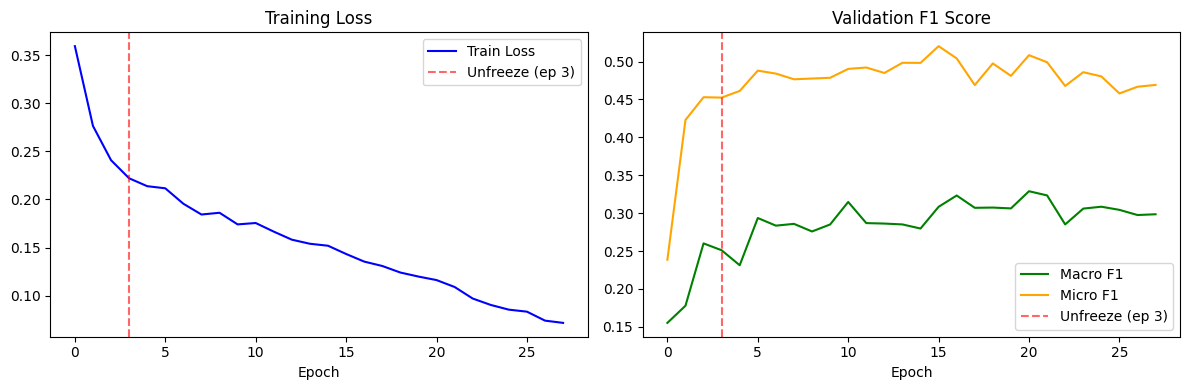

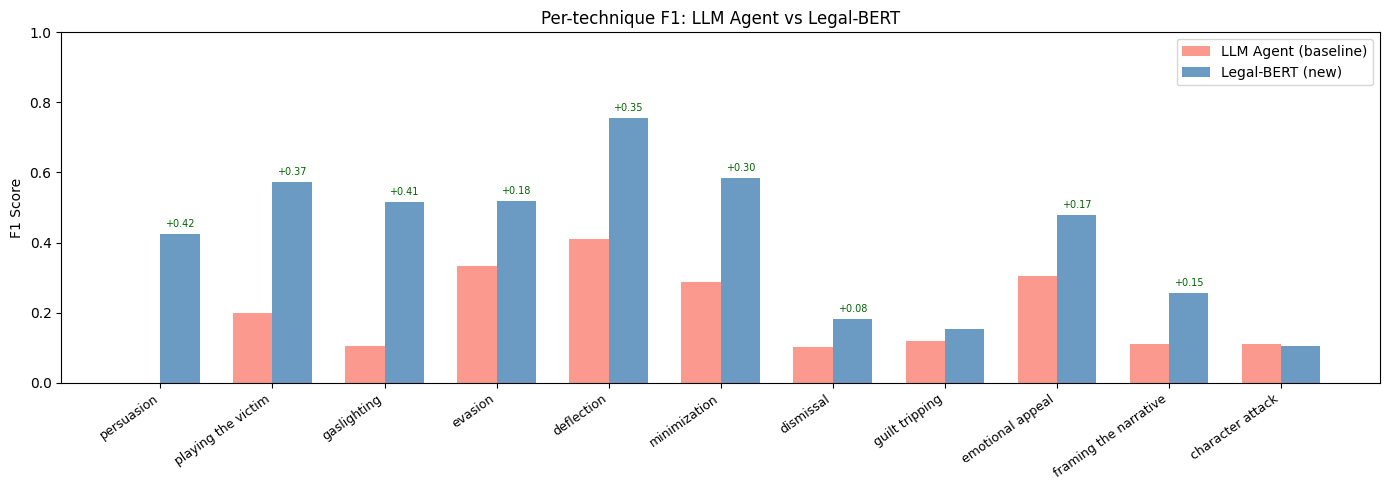

In [12]:
 
# Plots
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
 
axes[0].plot(history['train_loss'], label='Train Loss', color='blue')
axes[0].axvline(x=FREEZE_EPOCHS, color='red', linestyle='--', alpha=0.6,
                label=f'Unfreeze (ep {FREEZE_EPOCHS})')
axes[0].set_title('Training Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()
 
axes[1].plot(history['val_macro_f1'], label='Macro F1', color='green')
axes[1].plot(history['val_micro_f1'], label='Micro F1', color='orange')
axes[1].axvline(x=FREEZE_EPOCHS, color='red', linestyle='--', alpha=0.6,
                label=f'Unfreeze (ep {FREEZE_EPOCHS})')
axes[1].set_title('Validation F1 Score')
axes[1].set_xlabel('Epoch')
axes[1].legend()
 
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/training_history.png", dpi=150)
plt.show()
 
per_tech_f1_new = [
    f1_score(val_labels_arr[:, i], val_preds[:, i], zero_division=0)
    for i in range(NUM_LABELS)
]
per_tech_f1_old = [baseline_f1.get(t, 0) for t in TECHNIQUES]
 
x = np.arange(NUM_LABELS)
w = 0.35
fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(x - w / 2, per_tech_f1_old, w, label='LLM Agent (baseline)', color='salmon',   alpha=0.8)
ax.bar(x + w / 2, per_tech_f1_new, w, label='Legal-BERT (new)',     color='steelblue', alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(TECHNIQUES, rotation=35, ha='right', fontsize=9)
ax.set_ylabel('F1 Score')
ax.set_title('Per-technique F1: LLM Agent vs Legal-BERT (Fixed)')
ax.legend()
ax.set_ylim(0, 1)
for i, (old, new) in enumerate(zip(per_tech_f1_old, per_tech_f1_new)):
    if new - old > 0.05:
        ax.annotate(f'+{new - old:.2f}', xy=(x[i] + w / 2, new + 0.02),
                    ha='center', fontsize=7, color='darkgreen')
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/f1_comparison.png", dpi=150)
plt.show()

## 10. Inference - Tích hợp vào Pipeline

In [20]:
class TechniqueClassifier:
    """
    Wrapper để tích hợp vào LangGraph pipeline.
    Thay thế evidence_agent + analyzer_agent (phần technique).
    """
    def __init__(self, model_dir, base_model=BASE_MODEL):
        self.tokenizer = AutoTokenizer.from_pretrained(base_model)
        # FIX: bỏ focal_gamma, không truyền train_labels khi load từ file
        self.model = ManipulationClassifier(
            base_model, NUM_LABELS,
            dropout=DROPOUT
        ).to(DEVICE)
        self.model.load_state_dict(
            torch.load(f"{model_dir}/best_model.pt", map_location=DEVICE)
        )
        self.model.eval()
        self.thresholds = np.load(f"{model_dir}/best_thresholds.npy")
        print(f"Classifier loaded from {model_dir}")
        print(f"Thresholds: {dict(zip(TECHNIQUES, self.thresholds.round(2)))}")
 
    def predict(self, dialogue, plaintiff_intent=None, defendant_intent=None):
        if plaintiff_intent and defendant_intent:
            text = (f"[PLAINTIFF INTENT] {plaintiff_intent} "
                    f"[DEFENDANT INTENT] {defendant_intent} "
                    f"[DIALOGUE] {dialogue}")
        else:
            text = dialogue
 
        inputs = self.tokenizer(
            text, return_tensors='pt',
            truncation=True, max_length=MAX_LENGTH, padding=True
        )
        inputs = {k: v for k, v in inputs.items()
                  if k in ['input_ids', 'attention_mask']}
        inputs = {k: v.to(DEVICE) for k, v in inputs.items()}
 
        with torch.no_grad():
            _, logits = self.model(**inputs)
            probs = torch.sigmoid(logits).cpu().numpy()[0]
 
        techniques = [TECHNIQUES[i] for i, p in enumerate(probs) if p >= self.thresholds[i]]
        confidence = {TECHNIQUES[i]: float(probs[i]) for i in range(NUM_LABELS)}
        return techniques, confidence
 
 
# Test inference
classifier = TechniqueClassifier(OUTPUT_DIR)
 
sample_text   = val_texts[3]
sample_labels = [TECHNIQUES[i] for i, v in enumerate(val_labels[3]) if v == 1]
pred_techs, conf = classifier.predict(sample_text)
 
print(f"\nSample (truncated): {sample_text[:300]}...")
print(f"True labels:      {sample_labels}")
print(f"Predicted labels: {pred_techs}")
print(f"\nTop-5 confidences:")
for tech, p in sorted(conf.items(), key=lambda x: -x[1])[:5]:
    thresh = classifier.thresholds[TECHNIQUES.index(tech)]
    flag   = "✓" if p >= thresh else " "
    print(f"  {flag} {tech:<25} prob={p:.3f}  thresh={thresh:.2f}")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: nlpaueb/legal-bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Classifier loaded from /kaggle/working/bert_classifier
Thresholds: {'persuasion': np.float64(0.5), 'playing the victim': np.float64(0.55), 'gaslighting': np.float64(0.45), 'evasion': np.float64(0.55), 'deflection': np.float64(0.3), 'minimization': np.float64(0.45), 'dismissal': np.float64(0.45), 'guilt tripping': np.float64(0.5), 'emotional appeal': np.float64(0.25), 'framing the narrative': np.float64(0.4), 'character attack': np.float64(0.15)}

Sample (truncated): Judge: This is the Defendant, Brian Failen. He says he needed a pool cover for his pool because he didn't want his kids falling in and drowning if he took his eye off them for a minute. He had discussions with the Plaintiff about a pool cover but never made a deal with him to get one. He has no idea why the Plaintiff went off and ordered him a custom cover because he never signed off on anything. Besides, he doesn't even need a custom cover because his pool is just a standard pool, and a store-bought cover would have fit.
J

## 11. Chạy trên Test Set & Export CSV

In [21]:
test_df = pd.read_csv(TEST_CSV)
print(f"Test samples: {len(test_df)}")
 
HAS_INTENT_IN_TEST = COL_PLAINTIFF in test_df.columns and COL_DEFENDANT in test_df.columns
print(f"Has intent columns: {HAS_INTENT_IN_TEST}")
 
results = []
for i, row in test_df.iterrows():
    dialogue  = str(row[COL_DIALOGUE])
    plaintiff = str(row[COL_PLAINTIFF]) if HAS_INTENT_IN_TEST and pd.notna(row.get(COL_PLAINTIFF)) else None
    defendant = str(row[COL_DEFENDANT]) if HAS_INTENT_IN_TEST and pd.notna(row.get(COL_DEFENDANT)) else None
 
    techniques, confidence = classifier.predict(dialogue, plaintiff, defendant)
 
    results.append({
        'index':      i,
        'techniques': ', '.join(techniques) if techniques else 'None',
        'count':      len(techniques)
    })
 
    if i % 20 == 0:
        print(f"  [{i + 1}/{len(test_df)}] {techniques}")
 
results_df = pd.DataFrame(results)
test_df['BERT_Techniques'] = results_df['techniques'].values
 
output_path = f"{OUTPUT_DIR}/test_predictions.csv"
test_df.to_csv(output_path, index=False)
print(f"\nSaved to: {output_path}")
 
print("\n=== Predicted Technique Distribution ===")
all_pred = [t for ts in results_df['techniques'] for t in ts.split(', ') if t != 'None']
pred_counter = Counter(all_pred)
for tech in TECHNIQUES:
    c = pred_counter.get(tech, 0)
    print(f"  {tech:<25} {c:>4}")
 

Test samples: 155
Has intent columns: True
  [1/155] []
  [21/155] ['playing the victim', 'deflection', 'minimization', 'emotional appeal']
  [41/155] ['playing the victim', 'gaslighting', 'evasion', 'deflection', 'emotional appeal', 'character attack']
  [61/155] []
  [81/155] []
  [101/155] ['persuasion', 'evasion', 'deflection', 'minimization', 'framing the narrative']
  [121/155] ['deflection']
  [141/155] ['persuasion', 'playing the victim', 'evasion', 'deflection', 'minimization', 'dismissal', 'emotional appeal', 'framing the narrative', 'character attack']

Saved to: /kaggle/working/bert_classifier/test_predictions.csv

=== Predicted Technique Distribution ===
  persuasion                  43
  playing the victim          40
  gaslighting                 34
  evasion                     23
  deflection                  95
  minimization                52
  dismissal                   14
  guilt tripping               5
  emotional appeal            41
  framing the narrative    